In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Load cleaned transaction data
raw_path = Path("../data/raw/online_retail_ii.xlsx")
tx = pd.read_excel(raw_path)

# Normalize columns
tx = tx.rename(columns={
    "Customer ID": "CustomerID",
    "Price": "UnitPrice",
}).copy()

tx["InvoiceDate"] = pd.to_datetime(tx["InvoiceDate"], errors="coerce")
tx["Invoice"] = tx["Invoice"].astype(str)

# Core cleaning (same as prior projects)
tx = tx.dropna(subset=["CustomerID", "InvoiceDate", "Quantity", "UnitPrice"])
tx = tx.loc[~tx["Invoice"].str.startswith("C")]
tx = tx.loc[tx["Quantity"] > 0]
tx = tx.loc[tx["UnitPrice"] > 0]

tx["LineRevenue"] = tx["Quantity"] * tx["UnitPrice"]
tx["StockCode"] = tx["StockCode"].astype(str)

tx.head(), tx.shape

(  Invoice StockCode                          Description  Quantity  \
 0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
 1  489434    79323P                   PINK CHERRY LIGHTS        12   
 2  489434    79323W                  WHITE CHERRY LIGHTS        12   
 3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
 4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
 
           InvoiceDate  UnitPrice  CustomerID         Country  LineRevenue  
 0 2009-12-01 07:45:00       6.95     13085.0  United Kingdom         83.4  
 1 2009-12-01 07:45:00       6.75     13085.0  United Kingdom         81.0  
 2 2009-12-01 07:45:00       6.75     13085.0  United Kingdom         81.0  
 3 2009-12-01 07:45:00       2.10     13085.0  United Kingdom        100.8  
 4 2009-12-01 07:45:00       1.25     13085.0  United Kingdom         30.0  ,
 (407664, 9))

In [2]:
sku_price_stats = (
    tx.groupby("StockCode")
      .agg(
          n_transactions=("Invoice", "count"),
          n_unique_prices=("UnitPrice", "nunique"),
          min_price=("UnitPrice", "min"),
          max_price=("UnitPrice", "max"),
          avg_price=("UnitPrice", "mean"),
          total_units=("Quantity", "sum"),
          total_revenue=("LineRevenue", "sum"),
      )
      .reset_index()
)

sku_price_stats.head()

,StockCode,n_transactions,n_unique_prices,min_price,max_price,avg_price,total_units,total_revenue
0,10002,268,2,0.72,0.85,0.839813,7801,6061.97
1,10080,6,1,0.85,0.85,0.850000,12,10.20
2,10109,1,1,0.42,0.42,0.420000,4,1.68
3,10120,36,1,0.21,0.21,0.210000,471,98.91
4,10123C,47,3,0.06,0.65,0.622340,627,226.11


In [3]:
sku_price_stats["n_unique_prices"].value_counts().sort_index().head(10)

1     1375
2     1981
3      497
4      112
5       27
6       10
7        9
8        3
32       1
35       1
Name: n_unique_prices, dtype: int64

In [4]:
sku_price_stats["n_unique_prices"].value_counts().sort_index().tail(10)

2      1981
3       497
4       112
5        27
6        10
7         9
8         3
32        1
35        1
137       1
Name: n_unique_prices, dtype: int64

In [5]:
pricing_candidates = sku_price_stats.loc[
    (sku_price_stats["n_unique_prices"] >= 4) &
    (sku_price_stats["n_transactions"] >= 50)
].copy()

pricing_candidates.shape

(132, 8)

In [6]:
pricing_candidates.sort_values("total_revenue", ascending=False).head(10)

,StockCode,n_transactions,n_unique_prices,min_price,max_price,avg_price,total_units,total_revenue
3481,85123A,3153,6,1.90,3.24,2.855690,56915,151624.31
4011,M,425,137,0.10,10953.50,227.255388,2630,98560.64
4013,POST,738,35,1.00,850.00,27.052615,2212,48741.08
2505,48138,1025,8,4.00,7.95,7.223824,6349,41275.99
2865,84347,262,5,1.66,2.55,2.506527,21591,40186.65
216,20685,936,8,4.00,7.95,7.210064,5644,36431.28
23,15056N,497,4,3.00,5.95,5.729175,7201,34044.75
22,15056BL,547,4,3.00,5.95,5.744881,6709,31457.55
1574,22386,937,4,1.18,1.95,1.923010,17546,31149.60
1394,22189,700,6,2.30,3.95,3.873757,9918,29911.72


In [7]:
tx["StockCode"].nunique()

4017

In [8]:
(sku_price_stats["n_unique_prices"] >= 4).sum()

164

In [9]:
pricing_candidates.shape

(132, 8)

In [10]:
pricing_candidates.sort_values("total_revenue", ascending=False).head(10)

,StockCode,n_transactions,n_unique_prices,min_price,max_price,avg_price,total_units,total_revenue
3481,85123A,3153,6,1.90,3.24,2.855690,56915,151624.31
4011,M,425,137,0.10,10953.50,227.255388,2630,98560.64
4013,POST,738,35,1.00,850.00,27.052615,2212,48741.08
2505,48138,1025,8,4.00,7.95,7.223824,6349,41275.99
2865,84347,262,5,1.66,2.55,2.506527,21591,40186.65
216,20685,936,8,4.00,7.95,7.210064,5644,36431.28
23,15056N,497,4,3.00,5.95,5.729175,7201,34044.75
22,15056BL,547,4,3.00,5.95,5.744881,6709,31457.55
1574,22386,937,4,1.18,1.95,1.923010,17546,31149.60
1394,22189,700,6,2.30,3.95,3.873757,9918,29911.72


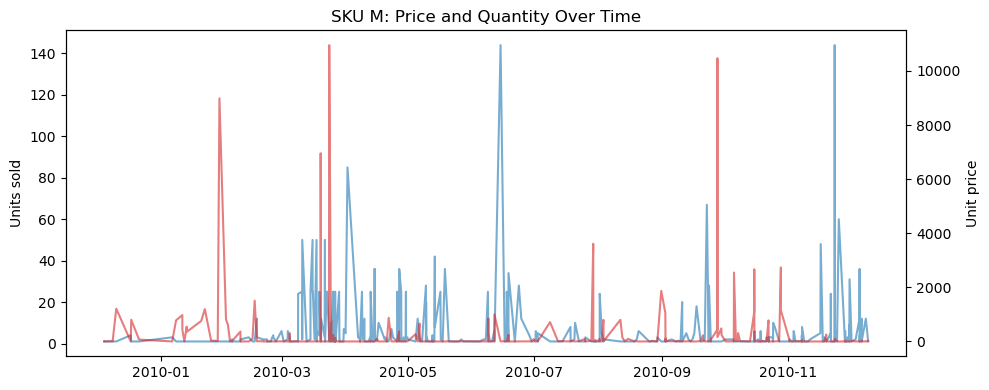

In [11]:
sku_code = "M"

sku_tx = tx.loc[tx["StockCode"] == sku_code].copy()
sku_tx = sku_tx.sort_values("InvoiceDate")

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    sku_tx["InvoiceDate"],
    sku_tx["Quantity"],
    label="Quantity sold",
    color="tab:blue",
    alpha=0.6
)
ax1.set_ylabel("Units sold")

ax2 = ax1.twinx()
ax2.plot(
    sku_tx["InvoiceDate"],
    sku_tx["UnitPrice"],
    label="Unit price",
    color="tab:red",
    alpha=0.6
)
ax2.set_ylabel("Unit price")

plt.title(f"SKU {sku_code}: Price and Quantity Over Time")
fig.tight_layout()
plt.show()


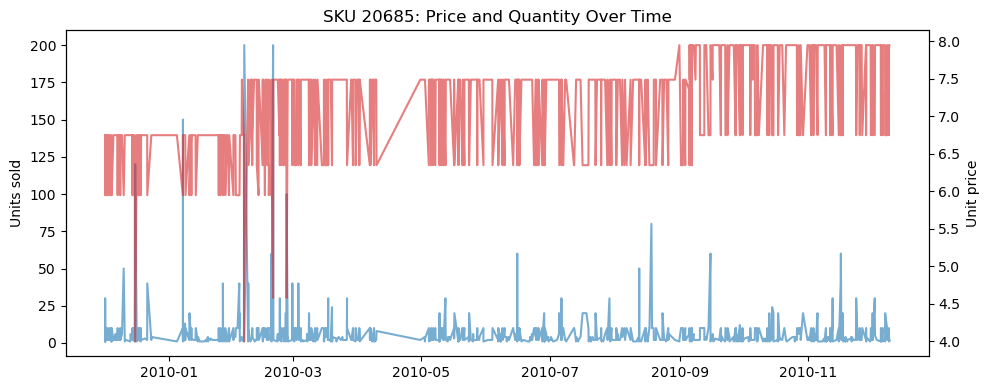

In [12]:
sku_code = "20685"

sku_tx = tx.loc[tx["StockCode"] == sku_code].copy()
sku_tx = sku_tx.sort_values("InvoiceDate")

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    sku_tx["InvoiceDate"],
    sku_tx["Quantity"],
    label="Quantity sold",
    color="tab:blue",
    alpha=0.6
)
ax1.set_ylabel("Units sold")

ax2 = ax1.twinx()
ax2.plot(
    sku_tx["InvoiceDate"],
    sku_tx["UnitPrice"],
    label="Unit price",
    color="tab:red",
    alpha=0.6
)
ax2.set_ylabel("Unit price")

plt.title(f"SKU {sku_code}: Price and Quantity Over Time")
fig.tight_layout()
plt.show()


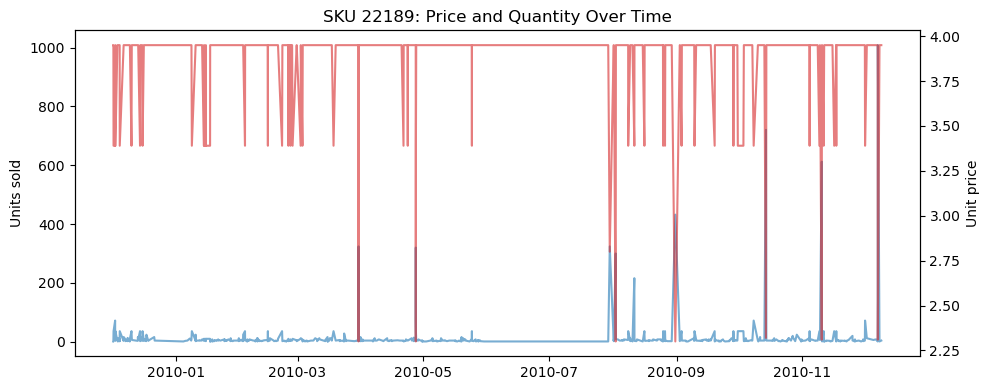

In [13]:
sku_code = "22189"

sku_tx = tx.loc[tx["StockCode"] == sku_code].copy()
sku_tx = sku_tx.sort_values("InvoiceDate")

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    sku_tx["InvoiceDate"],
    sku_tx["Quantity"],
    label="Quantity sold",
    color="tab:blue",
    alpha=0.6
)
ax1.set_ylabel("Units sold")

ax2 = ax1.twinx()
ax2.plot(
    sku_tx["InvoiceDate"],
    sku_tx["UnitPrice"],
    label="Unit price",
    color="tab:red",
    alpha=0.6
)
ax2.set_ylabel("Unit price")

plt.title(f"SKU {sku_code}: Price and Quantity Over Time")
fig.tight_layout()
plt.show()


In [14]:
import pandas as pd
from pathlib import Path

pricing_flags = pd.DataFrame([
    {
        "StockCode": "22189",
        "price_elasticity_class": "High",
        "evidence": "Discounted weeks ~4x higher revenue/week; strong volume response to small price drops"
    }
])

out_path = Path("../data/processed/sku_pricing_flags.csv")
pricing_flags.to_csv(out_path, index=False)
out_path

WindowsPath('../data/processed/sku_pricing_flags.csv')